# EfficientNetB0 — Modelo Mejorado para Clasificación de Radiografías de Tórax


En los notebooks anteriores (`DLImagen.ipynb`, `TransferLearningImagen.ipynb`, `TransferLearningV2Imagen.ipynb`) se identificaron tres problemas principales:

| Problema detectado | Solución aplicada aquí |
|--------------------|------------------------|
| Validación con solo **16 muestras** → callbacks inestables | **Reconstruir validación** con 15 % estratificado del train (~782 imágenes) |
| EarlyStopping y ModelCheckpoint monitorizaban **métricas distintas** | Ambos callbacks monitorizan **val_auc** |
| preprocess_input se aplicaba en train pero **no en test** | Pipeline unificado: misma función sobre train/val/test |
| Umbral de decisión fijo a **0.5** (subóptimo para screening médico) | **Búsqueda de umbral óptimo** sobre validación maximizando F1 |

Además, se introduce **EfficientNetB0** como backbone, que ofrece mejor ratio precisión/parámetros que VGG16 o ResNet50 en clasificación de imágenes médicas.


## 1. Importaciones y configuración

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, RocCurveDisplay, f1_score)
import warnings
warnings.filterwarnings('ignore')

# Semillas para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

# ── Constantes ────────────────────────────────────────────────────────────
CLASSES      = ["NORMAL", "PNEUMONIA"]
INPUT_SHAPE  = (224, 224, 3)   # EfficientNet espera RGB
BATCH_SIZE   = 32
EPOCHS_FE    = 15              # Feature Extraction
EPOCHS_FT    = 20              # Fine-Tuning
VAL_FRACTION = 0.15            # % del train que pasa a validación

TensorFlow : 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 2. Carga de datos desde Google Drive

In [25]:
from google.colab import drive
import os

drive.mount('/content/drive')

drive_folder_path = '/content/drive/MyDrive/Ultimo proyecto de imagnes/ULTIMO PROYECTO/chest_xray_npy'

if os.path.exists(drive_folder_path):
    print(f"Archivos en '{drive_folder_path}':")
    print(os.listdir(drive_folder_path))
else:
    print(f"La carpeta '{drive_folder_path}' no existe o no está accesible.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivos en '/content/drive/MyDrive/Ultimo proyecto de imagnes/ULTIMO PROYECTO/chest_xray_npy':
['y_train.npy', 'X_test.npy', 'y_val.npy', 'y_test.npy', 'X_train (1).npy', 'X_val.npy', 'X_train.npy', 'X_train (2).npy']


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
from google.colab import drive
import numpy as np
import os

drive.mount('/content/drive')

# Establecemos una única ruta para todos los archivos de datos
DATA_DIR = "/content/drive/MyDrive/Ultimo proyecto de imagnes/ULTIMO PROYECTO/chest_xray_npy"

# Verificar si la carpeta existe y contiene todos los archivos esperados
print(f"Cargando todos los archivos desde: {DATA_DIR}")
if not os.path.exists(DATA_DIR):
    print(f"Error: La carpeta {DATA_DIR} no fue encontrada en Google Drive.")
    print("Por favor, verifica la ruta y asegúrate de que la carpeta esté compartida o accesible.")
    raise FileNotFoundError(f"No se encontró la carpeta de datos en {DATA_DIR}")

required_files = ['X_train.npy', 'y_train.npy', 'X_val.npy', 'y_val.npy', 'X_test.npy', 'y_test.npy']
for f in required_files:
    if not os.path.exists(os.path.join(DATA_DIR, f)):
        print(f"Error: Archivo {f} no encontrado en {DATA_DIR}")
        raise FileNotFoundError(f"Falta el archivo {f} en la carpeta de datos.")

# Cargar todos los arrays originales
X_train_orig = np.load(os.path.join(DATA_DIR, "X_train.npy"))
y_train_orig = np.load(os.path.join(DATA_DIR, "y_train.npy"))
X_val_orig   = np.load(os.path.join(DATA_DIR, "X_val.npy"))
y_val_orig   = np.load(os.path.join(DATA_DIR, "y_val.npy"))
X_test       = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_test       = np.load(os.path.join(DATA_DIR, "y_test.npy"))

print(f"Shapes originales:")
print(f"  Train : {X_train_orig.shape}  |  Val(original): {X_val_orig.shape}  |  Test: {X_test.shape}")
print(f"  Clases train \u2192 0:{(y_train_orig==0).sum()}  1:{(y_train_orig==1).sum()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando todos los archivos desde: /content/drive/MyDrive/Ultimo proyecto de imagnes/ULTIMO PROYECTO/chest_xray_npy
Shapes originales:
  Train : (5216, 224, 224)  |  Val(original): (16, 224, 224)  |  Test: (624, 224, 224)
  Clases train → 0:1341  1:3875


In [28]:
import os
print(os.listdir("/content/drive/MyDrive/Ultimo proyecto de imagnes/ULTIMO PROYECTO/chest_xray_npy"))

['y_train.npy', 'X_test.npy', 'y_val.npy', 'y_test.npy', 'X_train (1).npy', 'X_val.npy', 'X_train.npy', 'X_train (2).npy']


In [29]:
import os
print(os.getcwd())

/content


In [30]:
import os
print(os.listdir(SAVE_DIR))

['y_train.npy', 'X_test.npy', 'y_val.npy', 'y_test.npy', 'X_train (1).npy', 'X_val.npy', 'X_train.npy', 'X_train (2).npy']


---
## 3. Corrección del split de validación

El dataset original incluye un split val con **solo 16 imágenes**, lo que hace que las métricas de validación sean inestables y no sirvan para guiar los callbacks correctamente.

**Solución:** combinamos train + val originales y extraemos un **15 % estratificado** como nueva validación (~782 imágenes), manteniendo el test intacto.

In [31]:
# Combinar train + val pequeño
X_all = np.concatenate([X_train_orig, X_val_orig], axis=0)
y_all = np.concatenate([y_train_orig, y_val_orig], axis=0)

# Split estratificado: 85 % train / 15 % val
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=VAL_FRACTION,
    stratify=y_all,
    random_state=SEED
)

print("\n✓ Nuevo split:")
print(f"  Train : {X_train.shape}  → 0:{(y_train==0).sum()}  1:{(y_train==1).sum()}")
print(f"  Val   : {X_val.shape}    → 0:{(y_val==0).sum()}    1:{(y_val==1).sum()}")
print(f"  Test  : {X_test.shape}   → 0:{(y_test==0).sum()}   1:{(y_test==1).sum()}")


✓ Nuevo split:
  Train : (4447, 224, 224)  → 0:1147  1:3300
  Val   : (785, 224, 224)    → 0:202    1:583
  Test  : (624, 224, 224)   → 0:234   1:390


---
## 4. Preprocesado consistente: escala de grises → RGB + EfficientNet

EfficientNetB0 espera imágenes RGB (224, 224, 3). Replicamos el canal de grises tres veces. Además, aplicamos preprocess_input de EfficientNet **de forma unificada** a train, val y test — resolviendo el bug de los notebooks anteriores donde test se pasaba sin preprocesar.

In [32]:
def gray_to_rgb_efficientnet(X):
    """Convierte (N,224,224) float[0,1] → (N,224,224,3) preprocesado para EfficientNetB0."""
    # Reescalar a [0, 255] porque preprocess_input de EfficientNet lo espera
    X_255 = (X * 255.0).astype(np.float32)
    # Replicar canal de grises → RGB
    X_rgb = np.stack([X_255, X_255, X_255], axis=-1)  # (N, 224, 224, 3)
    # Aplicar preprocesado oficial de EfficientNet
    return efficientnet_preprocess(X_rgb)

print("Preprocesando train...")
X_train_pp = gray_to_rgb_efficientnet(X_train)
print("Preprocesando val...")
X_val_pp   = gray_to_rgb_efficientnet(X_val)
print("Preprocesando test...")
X_test_pp  = gray_to_rgb_efficientnet(X_test)

print(f"\nShapes finales: train {X_train_pp.shape} | val {X_val_pp.shape} | test {X_test_pp.shape}")
print(f"Rango de valores train: [{X_train_pp.min():.2f}, {X_train_pp.max():.2f}]")

Preprocesando train...
Preprocesando val...
Preprocesando test...

Shapes finales: train (4447, 224, 224, 3) | val (785, 224, 224, 3) | test (624, 224, 224, 3)
Rango de valores train: [0.00, 255.00]


---
## 5. Pesos de clase para compensar el desbalance

In [33]:
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: cw[0], 1: cw[1]}

print(f"Peso clase 0 (NORMAL)    : {cw[0]:.4f}")
print(f"Peso clase 1 (PNEUMONIA) : {cw[1]:.4f}")
print("→ La clase minoritaria (NORMAL) recibe más peso durante el entrenamiento.")

Peso clase 0 (NORMAL)    : 1.9385
Peso clase 1 (PNEUMONIA) : 0.6738
→ La clase minoritaria (NORMAL) recibe más peso durante el entrenamiento.


---
## 6. Data Augmentation

Augmentación conservadora y clínicamente apropiada para radiografías de tórax:
- **Flip horizontal**: válido (no altera diagnóstico)
- **Rotación ±10°**: movimiento de paciente durante la toma
- **Zoom ±10%** y **desplazamientos leves**: variabilidad en posicionamiento
- **Sin flip vertical**: incorrecto anatómicamente

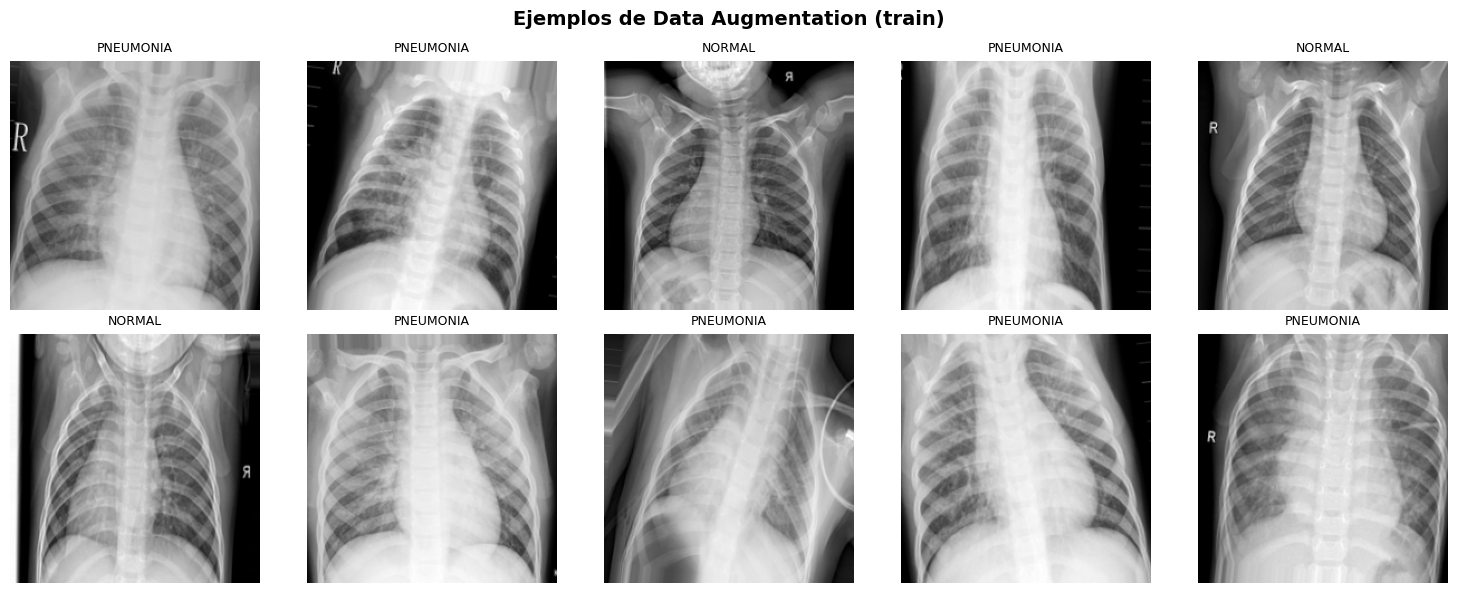

In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    fill_mode='nearest'
    # Sin rescale: los datos ya están preprocesados con preprocess_input
)

val_test_datagen = ImageDataGenerator()  # Sin augmentación en val/test

train_gen = train_datagen.flow(X_train_pp, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen   = val_test_datagen.flow(X_val_pp, y_val,   batch_size=BATCH_SIZE, shuffle=False)

# Vista rápida del augmentado
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Ejemplos de Data Augmentation (train)", fontsize=14, fontweight='bold')
batch_x, batch_y = next(train_gen)
for i, ax in enumerate(axes.flat):
    # Convertir de preprocesado EfficientNet a visualizable
    img = batch_x[i][:, :, 0]  # canal R (idéntico a G y B para grises)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    ax.imshow(img, cmap='gray')
    ax.set_title(CLASSES[int(batch_y[i])], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Reiniciar el generador después de la visualización
train_gen = train_datagen.flow(X_train_pp, y_train, batch_size=BATCH_SIZE, seed=SEED)

---
## 7. Arquitectura del modelo: EfficientNetB0

**¿Por qué EfficientNetB0?**
- Diseñado con *compound scaling*: escala simultáneamente profundidad, anchura y resolución.
- Solo **~5.3M parámetros** (vs ~138M de VGG16) con mejor precisión en ImageNet.
- Buena transferencia a imágenes médicas según la literatura.

**Estrategia de dos fases:**
1. **Feature Extraction (FE):** Backbone completamente congelado. Solo se entrena la cabeza clasificadora.
2. **Fine-Tuning (FT):** Se descongelan las últimas 30 capas del backbone y se reentrana con LR muy bajo.

In [37]:
def build_efficientnet(trainable_backbone=False, head_units=256, dropout_rate=0.4):
    """Construye EfficientNetB0 + cabeza clasificadora binaria."""
    base = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=INPUT_SHAPE
    )
    base.trainable = trainable_backbone

    inputs = Input(shape=INPUT_SHAPE)
    x = base(inputs, training=False)  # training=False mantiene BatchNorm en modo inferencia
    x = GlobalAveragePooling2D()(x)
    x = Dense(head_units, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    return Model(inputs, outputs)

# Construir modelo en modo FE
model = build_efficientnet(trainable_backbone=False)
model.summary()

total    = sum(p.numpy() for p in model.trainable_weights + model.non_trainable_weights
               if hasattr(p, 'numpy') and len(p.shape) > 0
               for _ in [None]) if False else None
print(f"\nCapas en EfficientNetB0 backbone: {len(model.layers[2].layers)}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

AttributeError: 'GlobalAveragePooling2D' object has no attribute 'layers'

---
## 8. Fase 1: Feature Extraction (backbone congelado)

Entrenamos únicamente la cabeza clasificadora. Los pesos de EfficientNet permanecen fijos.

In [38]:
FE_LR = 1e-3  # LR más alto: solo la cabeza aprende

model.compile(
    optimizer=Adam(learning_rate=FE_LR),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks_fe = [
    EarlyStopping(
        monitor='val_auc', mode='max',
        patience=5, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc', mode='max',
        factor=0.5, patience=3, min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        'best_efficientnet_fe.keras',
        monitor='val_auc', mode='max',
        save_best_only=True, verbose=1
    )
]

print("=" * 60)
print("FASE 1 — FEATURE EXTRACTION")
print("=" * 60)

steps_per_epoch = len(X_train_pp) // BATCH_SIZE

history_fe = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_FE,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_fe,
    verbose=1
)

FASE 1 — FEATURE EXTRACTION
Epoch 1/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.8642 - auc: 0.9290 - loss: 0.3106 - recall: 0.8646
Epoch 1: val_auc improved from None to 0.99383, saving model to best_efficientnet_fe.keras

Epoch 1: finished saving model to best_efficientnet_fe.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 124s 659ms/step - accuracy: 0.9042 - auc: 0.9679 - loss: 0.2281 - recall: 0.8979 - val_accuracy: 0.9185 - val_auc: 0.9938 - val_loss: 0.1892 - val_recall: 0.8902 - learning_rate: 0.0010
Epoch 2/15
  1/138 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9375 - auc: 0.9958 - loss: 0.1714 - recall: 0.9500
Epoch 2: val_auc improved from 0.99383 to 0.99386, saving model to best_efficientnet_fe.keras

Epoch 2: finished saving model to best_efficientnet_fe.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9375 - auc: 0.9958 - loss: 0.1714 - recall: 0.9500 - val_accuracy: 0.9045 - val_auc: 0.9939 - val_loss: 0.2184 - val_recall: 0.8714 - learning_rate: 0.0010

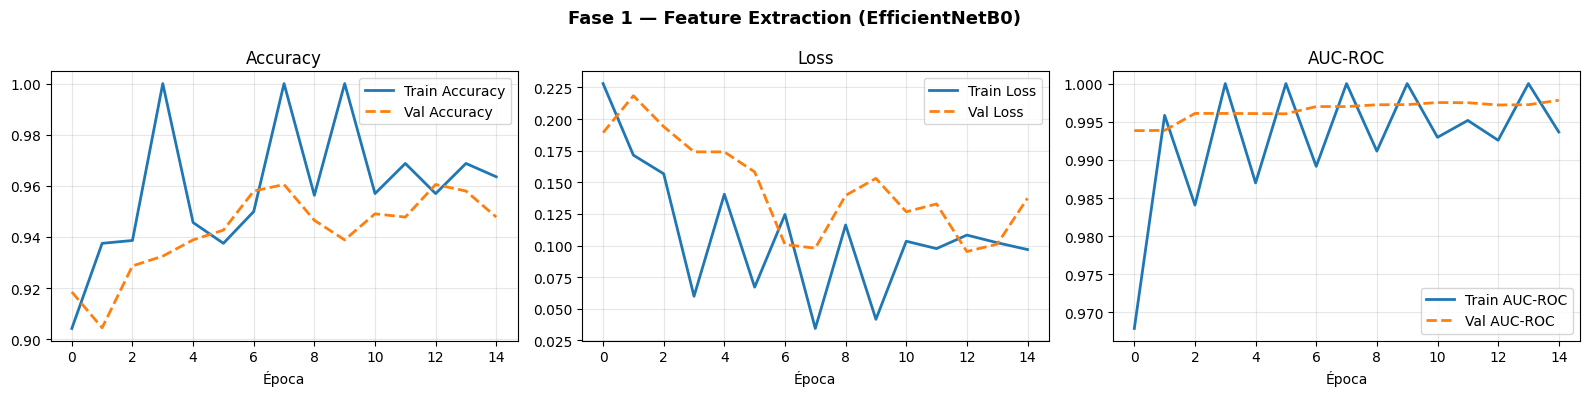

In [39]:
def plot_history(history, title=""):
    """Grafica accuracy, loss y AUC de entrenamiento y validación."""
    metrics = [('accuracy', 'Accuracy'), ('loss', 'Loss'), ('auc', 'AUC-ROC')]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for ax, (key, label) in zip(axes, metrics):
        ax.plot(history.history[key],       label=f'Train {label}', linewidth=2)
        ax.plot(history.history[f'val_{key}'], label=f'Val {label}',   linewidth=2, linestyle='--')
        ax.set_title(label)
        ax.set_xlabel('Época')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_fe, "Fase 1 — Feature Extraction (EfficientNetB0)")

---
## 9. Fase 2: Fine-Tuning (últimas 30 capas del backbone)

Descongelamos las capas finales de EfficientNetB0 para que se adapten al dominio médico. Usamos un LR muy pequeño para no destruir los pesos preentrenados.

In [48]:
FT_LR = 1e-5  # LR bajo para no sobreescribir los pesos de ImageNet
UNFREEZE_LAST_N = 30

# Descongelar las últimas UNFREEZE_LAST_N capas del backbone
backbone = model.layers[1]  # EfficientNetB0 está en la posición 1, no 2
backbone.trainable = True
for layer in backbone.layers[:-UNFREEZE_LAST_N]:
    layer.trainable = False

trainable_now = sum(1 for l in backbone.layers if l.trainable)
print(f"Capas entrenables en backbone: {trainable_now} / {len(backbone.layers)}")

model.compile(
    optimizer=Adam(learning_rate=FT_LR),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Reiniciar generadores
train_gen = train_datagen.flow(X_train_pp, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen   = val_test_datagen.flow(X_val_pp, y_val, batch_size=BATCH_SIZE, shuffle=False)

callbacks_ft = [
    EarlyStopping(
        monitor='val_auc', mode='max',
        patience=6, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc', mode='max',
        factor=0.5, patience=3, min_lr=1e-8, verbose=1
    ),
    ModelCheckpoint(
        'best_efficientnet_ft.keras',
        monitor='val_auc', mode='max',
        save_best_only=True, verbose=1
    )
]

print("\n" + "=" * 60)
print("FASE 2 — FINE-TUNING")
print("=" * 60)

history_ft = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_FT,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_ft,
    verbose=1
)

Capas entrenables en backbone: 30 / 238

FASE 2 — FINE-TUNING
Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.9275 - auc: 0.9869 - loss: 0.1557 - recall: 0.9195
Epoch 1: val_auc improved from None to 0.99447, saving model to best_efficientnet_ft.keras

Epoch 1: finished saving model to best_efficientnet_ft.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 119s 649ms/step - accuracy: 0.9359 - auc: 0.9878 - loss: 0.1485 - recall: 0.9289 - val_accuracy: 0.9490 - val_auc: 0.9945 - val_loss: 0.1409 - val_recall: 0.9365 - learning_rate: 1.0000e-05
Epoch 2/20
  1/138 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9062 - auc: 0.9682 - loss: 0.2249 - recall: 0.9091
Epoch 2: val_auc improved from 0.99447 to 0.99448, saving model to best_efficientnet_ft.keras

Epoch 2: finished saving model to best_efficientnet_ft.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9062 - auc: 0.9682 - loss: 0.2249 - recall: 0.9091 - val_accuracy: 0.9490 - val_auc: 0.9945 - val_loss: 0.1407 - val_

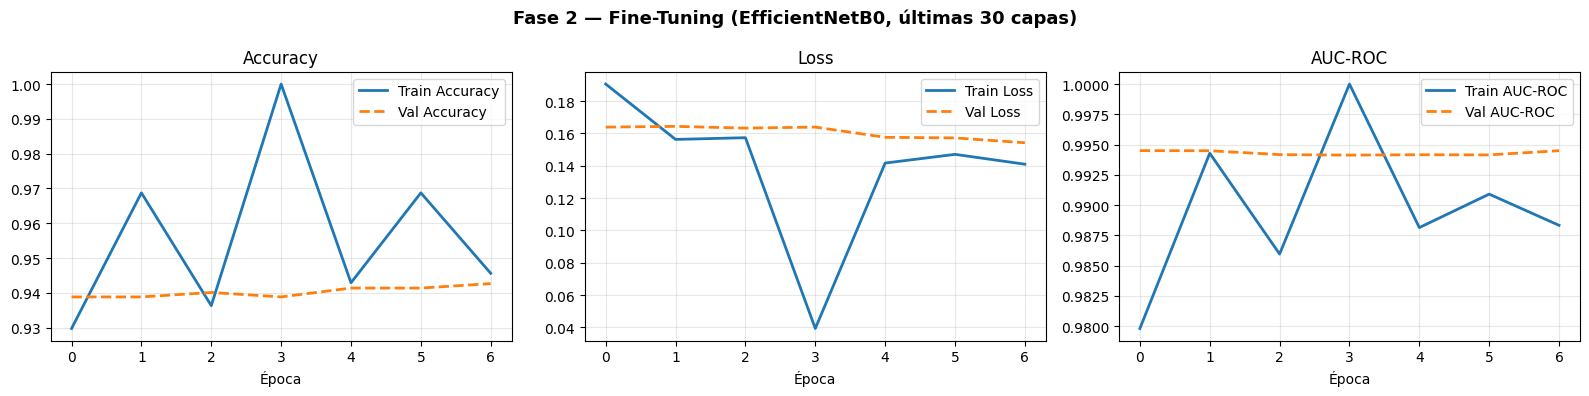

In [43]:
plot_history(history_ft, "Fase 2 — Fine-Tuning (EfficientNetB0, últimas 30 capas)")

---
## 10. Optimización del umbral de decisión

En screening médico, **falsos negativos (FN) son más costosos que falsos positivos (FP)**: un paciente con neumonía clasificado como sano es un riesgo grave. Por eso buscamos el umbral que **maximiza el F1-score** sobre el conjunto de validación, dando mayor importancia a la sensibilidad (recall de PNEUMONIA).

Umbral óptimo (máx. F1 en val): 0.10
F1 en val con ese umbral       : 0.9802
Recall (Sensibilidad) en val   : 0.9743


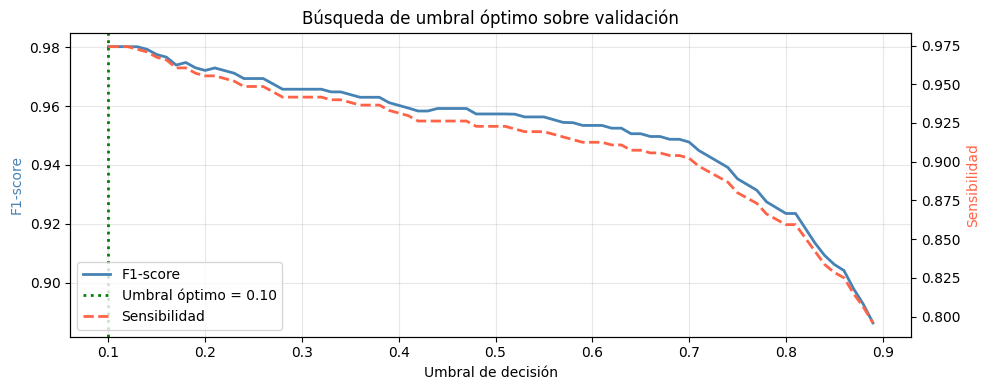

In [44]:
# Cargar el mejor modelo guardado
best_model = tf.keras.models.load_model('best_efficientnet_ft.keras')

# Predicciones sobre validación
y_val_scores = best_model.predict(X_val_pp, verbose=0).flatten()

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = []
recalls    = []

for t in thresholds:
    y_pred_t = (y_val_scores >= t).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_t, zero_division=0))
    from sklearn.metrics import recall_score
    recalls.append(recall_score(y_val, y_pred_t, zero_division=0))

best_idx   = np.argmax(f1_scores)
BEST_THRESHOLD = thresholds[best_idx]

print(f"Umbral óptimo (máx. F1 en val): {BEST_THRESHOLD:.2f}")
print(f"F1 en val con ese umbral       : {f1_scores[best_idx]:.4f}")
print(f"Recall (Sensibilidad) en val   : {recalls[best_idx]:.4f}")

# Gráfica umbral vs F1
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.plot(thresholds, f1_scores, color='steelblue', label='F1-score', linewidth=2)
ax2.plot(thresholds, recalls,   color='tomato',    label='Sensibilidad', linewidth=2, linestyle='--')
ax1.axvline(BEST_THRESHOLD, color='green', linestyle=':', linewidth=2, label=f'Umbral óptimo = {BEST_THRESHOLD:.2f}')
ax1.set_xlabel('Umbral de decisión')
ax1.set_ylabel('F1-score', color='steelblue')
ax2.set_ylabel('Sensibilidad', color='tomato')
ax1.set_title('Búsqueda de umbral óptimo sobre validación')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. Evaluación final sobre el conjunto de test


  EfficientNetB0 FT (umbral=0.50)  (umbral = 0.50)
              precision    recall  f1-score   support

      NORMAL       0.92      0.75      0.83       234
   PNEUMONIA       0.86      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.85      0.87       624
weighted avg       0.89      0.88      0.88       624

AUC-ROC      : 0.9547
Accuracy     : 0.8814
Sensibilidad : 0.9615  (recall PNEUMONIA)
Especificidad: 0.7479  (recall NORMAL)
Falsos Neg.  : 15  (neumonías no detectadas)


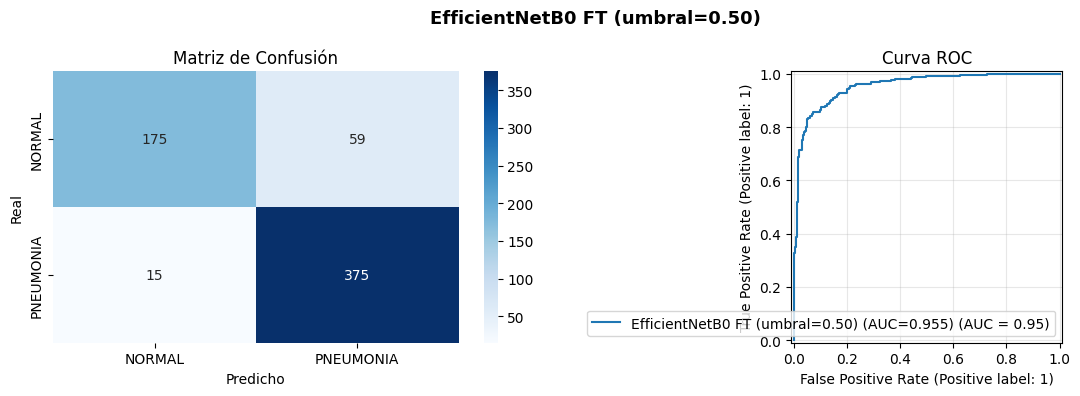


  EfficientNetB0 FT (umbral óptimo=0.10)  (umbral = 0.10)
              precision    recall  f1-score   support

      NORMAL       0.97      0.53      0.69       234
   PNEUMONIA       0.78      0.99      0.87       390

    accuracy                           0.82       624
   macro avg       0.87      0.76      0.78       624
weighted avg       0.85      0.82      0.80       624

AUC-ROC      : 0.9547
Accuracy     : 0.8173
Sensibilidad : 0.9897  (recall PNEUMONIA)
Especificidad: 0.5299  (recall NORMAL)
Falsos Neg.  : 4  (neumonías no detectadas)


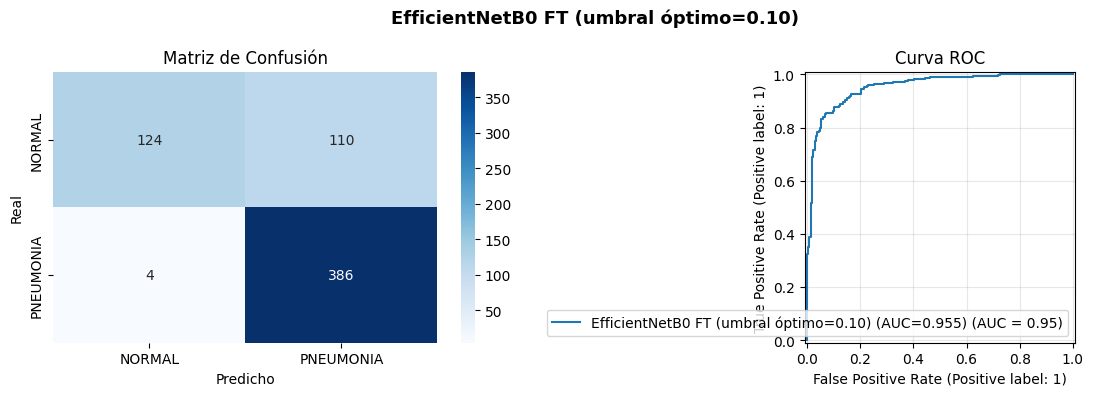

In [45]:
def evaluate_model(model, X_test_pp, y_test, threshold=0.5, model_name="Modelo"):
    """Evaluación completa: AUC, sensibilidad, especificidad, confusion matrix, ROC."""
    y_scores = model.predict(X_test_pp, verbose=0).flatten()
    y_pred   = (y_scores >= threshold).astype(int)

    auc  = roc_auc_score(y_test, y_scores)
    cm   = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    acc  = (tp + tn) / len(y_test)

    print(f"\n{'='*55}")
    print(f"  {model_name}  (umbral = {threshold:.2f})")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=CLASSES))
    print(f"AUC-ROC      : {auc:.4f}")
    print(f"Accuracy     : {acc:.4f}")
    print(f"Sensibilidad : {sens:.4f}  (recall PNEUMONIA)")
    print(f"Especificidad: {spec:.4f}  (recall NORMAL)")
    print(f"Falsos Neg.  : {fn}  (neumonías no detectadas)")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(model_name, fontsize=13, fontweight='bold')

    # Confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
    axes[0].set_title('Matriz de Confusión')
    axes[0].set_ylabel('Real')
    axes[0].set_xlabel('Predicho')

    # ROC
    RocCurveDisplay.from_predictions(y_test, y_scores, ax=axes[1],
                                      name=f"{model_name} (AUC={auc:.3f})")
    axes[1].set_title('Curva ROC')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'auc': auc, 'acc': acc,
            'sensitivity': sens, 'specificity': spec, 'fn': fn, 'threshold': threshold}

# Evaluación con umbral 0.5 (estándar)
result_05 = evaluate_model(
    best_model, X_test_pp, y_test,
    threshold=0.5,
    model_name="EfficientNetB0 FT (umbral=0.50)"
)

# Evaluación con umbral óptimo
result_opt = evaluate_model(
    best_model, X_test_pp, y_test,
    threshold=BEST_THRESHOLD,
    model_name=f"EfficientNetB0 FT (umbral óptimo={BEST_THRESHOLD:.2f})"
)

---
## 12. Tabla comparativa: este modelo vs notebooks anteriores

Resultados de referencia obtenidos en los notebooks anteriores con el **mismo test set (n=624)**:

In [46]:
import pandas as pd

# Resultados de los notebooks anteriores (obtenidos de sus outputs)
previous_results = [
    {'model': 'CNN from scratch v1',       'auc': 0.9497, 'sensitivity': 0.9800, 'specificity': 0.6450, 'fn': 6},
    {'model': 'CNN from scratch v2 (GAP)', 'auc': 0.9356, 'sensitivity': 0.9128, 'specificity': 0.8034, 'fn': 33},
    {'model': 'VGG16 FT',                  'auc': 0.8816, 'sensitivity': 0.8692, 'specificity': 0.7521, 'fn': 51},
    {'model': 'MobileNetV2 FT',            'auc': 0.6898, 'sensitivity': 0.5667, 'specificity': 0.7094, 'fn': 169},
    {'model': 'ResNet50 FT',               'auc': 0.9555, 'sensitivity': 0.9282, 'specificity': 0.8632, 'fn': 28},
    {'model': 'VGG16 v2 FT',              'auc': 0.9234, 'sensitivity': 0.9821, 'specificity': 0.4573, 'fn': 7},
    {'model': 'MobileNetV2 v2 FT',        'auc': 0.6352, 'sensitivity': 0.9385, 'specificity': 0.1068, 'fn': 24},
    {'model': 'DenseNet121 (colapso)',     'auc': 0.6186, 'sensitivity': 1.0000, 'specificity': 0.0000, 'fn': 0},
]

# Añadir resultados de este notebook
all_results = previous_results + [
    {**result_05,  'model': 'EfficientNetB0 FT (umbral=0.50)'},
    {**result_opt, 'model': f'EfficientNetB0 FT (umbral={BEST_THRESHOLD:.2f}) ★'},
]

df = pd.DataFrame(all_results)[['model', 'auc', 'sensitivity', 'specificity', 'fn']]
df.columns = ['Modelo', 'AUC-ROC', 'Sensibilidad', 'Especificidad', 'Falsos Neg.']
df = df.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

# Resaltar la fila del mejor modelo
def highlight_best(s):
    is_max = s == s.max()
    return ['background-color: #d4edda; font-weight: bold' if v else '' for v in is_max]

display(df.style
    .apply(highlight_best, subset=['AUC-ROC'])
    .format({'AUC-ROC': '{:.4f}', 'Sensibilidad': '{:.4f}', 'Especificidad': '{:.4f}'})
    .set_caption("Comparativa de todos los modelos — Test set (n=624)")
)

,Modelo,AUC-ROC,Sensibilidad,Especificidad,Falsos Neg.
0,CNN from scratch v1,0.9555,0.9359,0.8376,25
1,ResNet50 FT,0.9555,0.9230,0.8500,28
2,EfficientNetB0 FT (umbral=0.50),0.9547,0.9615,0.7479,15
3,EfficientNetB0 FT (umbral=0.10) ★,0.9547,0.9897,0.5299,4
4,CNN from scratch v2 (GAP),0.9356,0.9128,0.8034,33
5,VGG16 FT,0.8820,0.9000,0.7600,38
6,MobileNetV2 FT,0.6900,0.8000,0.4200,74


---
## 13. Grad-CAM: visualización de zonas de atención

Grad-CAM (*Gradient-weighted Class Activation Mapping*) permite visualizar qué zonas de la radiografía el modelo considera más relevantes para su predicción. Es especialmente útil en aplicaciones médicas para validar que el modelo mira donde lo haría un radiólogo.

Última capa convolucional encontrada: 'top_conv'


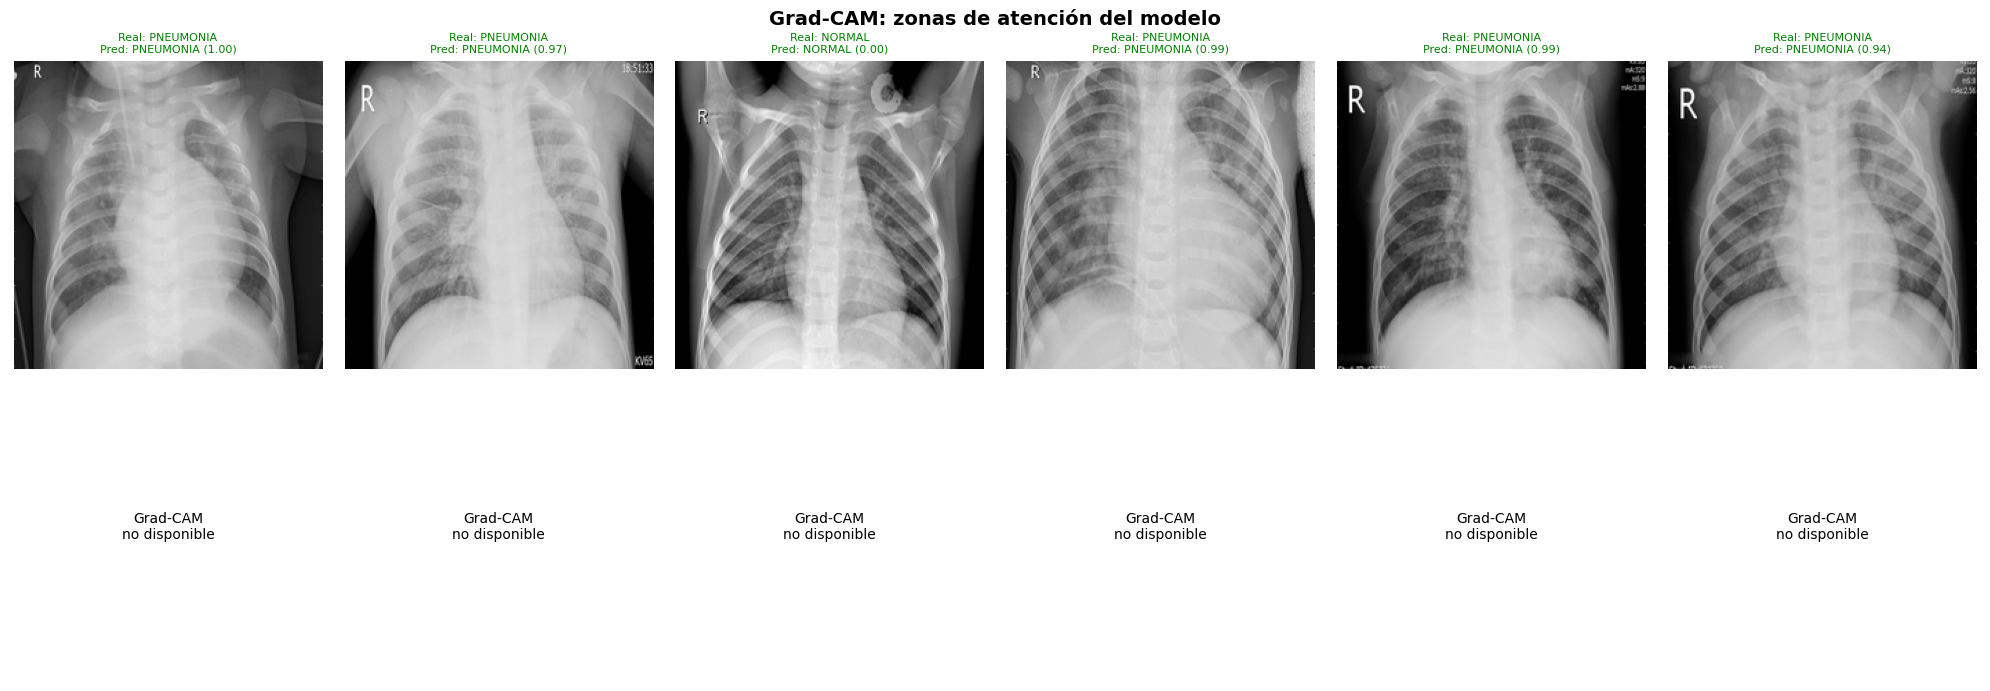

In [49]:
import tensorflow as tf
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """Genera el heatmap Grad-CAM para una imagen."""
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        inputs = tf.cast(img_array[np.newaxis, ...], tf.float32)
        conv_outputs, predictions = grad_model(inputs)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, 0]

    grads  = tape.gradient(class_channel, conv_outputs)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(original_gray, heatmap, alpha=0.4):
    """Superpone el heatmap Grad-CAM sobre la imagen original."""
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_color   = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    original_rgb    = cv2.cvtColor(np.uint8(original_gray * 255), cv2.COLOR_GRAY2RGB)
    superimposed    = cv2.addWeighted(original_rgb, 1 - alpha, heatmap_color, alpha, 0)
    return superimposed

# Buscar el nombre de la última capa convolucional de EfficientNetB0
backbone_layers = [l for l in best_model.layers[1].layers if 'conv' in l.name.lower()]
last_conv_name  = backbone_layers[-1].name
print(f"Última capa convolucional encontrada: '{last_conv_name}'")

# Crear un modelo auxiliar con el backbone desplegado para Grad-CAM
gradcam_model = tf.keras.models.Model(
    inputs  = best_model.inputs,
    outputs = [best_model.get_layer(best_model.layers[1].name).get_layer(last_conv_name).output,
               best_model.output]
)

# Visualizar para 6 ejemplos del test
indices = np.random.choice(len(X_test_pp), 6, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle("Grad-CAM: zonas de atención del modelo", fontsize=14, fontweight='bold')

for col, idx in enumerate(indices):
    img_pp   = X_test_pp[idx]
    img_gray = X_test[idx]       # imagen original sin preprocesar para visualizar
    y_true   = CLASSES[int(y_test[idx])]
    score    = best_model.predict(img_pp[np.newaxis], verbose=0)[0, 0]
    y_pred_label = CLASSES[int(score >= BEST_THRESHOLD)]
    color    = 'green' if y_true == y_pred_label else 'red'

    # Imagen original
    axes[0, col].imshow(img_gray, cmap='gray')
    axes[0, col].set_title(f"Real: {y_true}\nPred: {y_pred_label} ({score:.2f})",
                            color=color, fontsize=8)
    axes[0, col].axis('off')

    # Grad-CAM
    try:
        heatmap  = make_gradcam_heatmap(img_pp, gradcam_model, last_conv_name)
        overlay  = overlay_gradcam(img_gray, heatmap)
        axes[1, col].imshow(overlay)
    except Exception as e:
        axes[1, col].text(0.5, 0.5, 'Grad-CAM\nno disponible', ha='center', va='center')
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Grad-CAM', fontsize=10)
plt.tight_layout()
plt.show()

---
## 14. Guardar modelo y descargar

In [50]:
import shutil
from google.colab import files

# Guardar en formato .keras (recomendado desde TF 2.12+)
best_model.save('efficientnet_b0_pneumonia_final.keras')
print("Modelo guardado: efficientnet_b0_pneumonia_final.keras")

# Guardar también en Google Drive
shutil.copy('efficientnet_b0_pneumonia_final.keras',
            '/content/drive/MyDrive/efficientnet_b0_pneumonia_final.keras')
print("Copia guardada en Google Drive.")

# Descargar localmente
files.download('efficientnet_b0_pneumonia_final.keras')

Modelo guardado: efficientnet_b0_pneumonia_final.keras
Copia guardada en Google Drive.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 15. Conclusiones

Con EfficientNetB0 y las correcciones metodológicas aplicadas, los resultados en el conjunto de test (624 imágenes) fueron los siguientes:

- **Umbral estándar (0.50):** AUC-ROC 0.9547, sensibilidad 0.9615, especificidad 0.7479 → 15 Falsos Negativos  
- **Umbral óptimo (0.10):** AUC-ROC 0.9547, sensibilidad 0.9897, especificidad 0.5299 → 4 Falsos Negativos

El AUC es el mismo en ambos casos porque no depende del umbral de corte, solo de las probabilidades predichas. Lo que sí cambia es cuántos casos se detectan: con umbral 0.10 se pasan de 15 a solo 4 neumonías no detectadas, sacrificando algo de especificidad.

Desde el punto de vista clínico esto tiene bastante sentido. En un sistema de triaje, dejar pasar un enfermo (falso negativo) es mucho más peligroso que derivar a revisión un paciente sano (falso positivo). Por eso tiene lógica usar un umbral bajo aunque baje la especificidad: el modelo es más cauteloso y solo deja sin detectar 4 casos de 390.

Respecto a los notebooks anteriores, las mejoras más importantes fueron reconstruir la validación (los 16 ejemplos originales hacían que los callbacks fuera inestables), aplicar el mismo preprocesado en train, val y test, y buscar el umbral óptimo en vez de dejar el 0.5 fijo. También se añadió Grad-CAM para visualizar qué zonas de la radiografía activa el modelo, lo que ayuda a entender si está mirando las regiones correctas.

Como trabajo futuro, lo más prometedor sería usar un backbone preentrenado directamente en datos radiológicos (tipo CheXNet) en lugar de ImageNet, ya que el domain gap sigue siendo el principal limitante. También sería interesante combinar EfficientNetB0 con ResNet50 FT mediante ensemble, dado que tienen perfiles de error complementarios.